# Rebinned Cls-space posterior predictive (interactive)

Fast-iteration companion to `submissions/clariden/ppc.sh` for building the **Cls marginals** plot
(`msi.utils.ppc.PosteriorPredictiveChecks.check_cls_marginals`). Same inputs as the submission
(`run_ppc.py`), but the heavy setup runs **once** and you iterate on the last cell.

Run in `torch_env` (the same env `ppc.sh` uses):
```
uenv start --view=default pytorch/v2.9.1:v2
source ~/dlss/torch_env/bin/activate
```
Edits to `check_cls_marginals` / `cls_preprocessing` are picked up live via `autoreload` — no need to
rebuild the flow or reload the grid.

In [1]:
import sys

sys.path.insert(0, "../../../notebooks")  # the single shared copy of cluster_paths.py
from cluster_paths import get_cluster_paths
scratch_path, repo_path, backup_path = get_cluster_paths()

%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from msfm.utils.input_output import read_yaml
from deep_lss.utils import cls_preprocessing
from msi.apps import run_ppc                      # reuse the production helpers (single source of truth)


/users/athomsen/dlss/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config — same files `ppc.sh` passes to `run_ppc.py`

In [3]:
MSI = f"{repo_path}/multiprobe-simulation-inference"

runs_config = f"{MSI}/configs/runs/v17/baseline/t2_v3.yaml"          # has both cls/* and maps/* runs
ppc_config  = f"{MSI}/configs/ppc/ppc_quick.yaml"
msfm_config = f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/rot_in_place.yaml"

runs_conf = read_yaml(runs_config)
ppc_conf  = read_yaml(ppc_config)

cosmo_params = ppc_conf.get("cosmo_params", ["Om", "s8", "w0"])
seed         = ppc_conf.get("seed", 111)
n_flows      = ppc_conf.get("n_flows", 1)
flow_conf    = read_yaml(ppc_conf["flow_config"]) if ppc_conf.get("flow_config") else {}
cls_conf     = ppc_conf.get("cls_marginals", {})

# Resolve the rebinned-Cls cache config exactly as run_ppc does. The scale cut comes from the
# runs config (scales_config), the data location (base_dir) from the ppc config.
base_dir, cls_n_bins, scales_name, dlss_conf = run_ppc.resolve_rebinned_cls_cache(
    cls_conf, runs_conf["scales_config"]
)
print("base_dir   :", base_dir)
print("cls_n_bins :", cls_n_bins)
print("scales_name:", scales_name)


26-06-26 14:03:19   run_ppc.py INF   Cls PPD config: cache=/iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place/cls/rebinned_nb16_8wl,32gc.h5, scales_name=8wl,32gc, cls_n_bins=16, scale_cuts from /users/athomsen/dlss/repos/y3-deep-lss/configs/scales/8wl,32gc.yaml 
base_dir   : /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place
cls_n_bins : 16
scales_name: 8wl,32gc


## Pick a run

`cls/lensing` is the native rebinned-Cls path. Any `maps/*` run instead projects its maps posterior
into rebinned-Cls space (and exercises the exact realization-level alignment).

In [4]:
runs = list(run_ppc.iter_runs(runs_conf))
for i, r in enumerate(runs):
    print(f"[{i}] {r['data']:5s} {r['probe']:10s} steps={r['steps']}")

# choose one (edit the selector):
run = next(r for r in runs if r["data"] == "cls" and r["probe"] == "lensing")
print("\nselected:", run["data"], run["probe"], run["pred_dir"])


[0] maps  lensing    steps=300000
[1] maps  clustering steps=600000
[2] maps  combined   steps=250000
[3] cls   lensing    steps=1000000
[4] cls   clustering steps=1000000
[5] cls   2x2pt      steps=1000000
[6] cls   combined   steps=1000000

selected: cls lensing /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33


## Build PPC + set up the flow — run once

`retrain=False` loads the PPC auto-flow checkpoint if one exists; otherwise it trains a fresh one
(`fit_kwargs` keeps that quick). `_set_observation` sets `s_obs` / `theta_post`, which the
importance sampler in `check_cls_marginals` needs.

In [5]:
ppc = run_ppc.make_ppc(msfm_config, cosmo_params, seed, run, flow_conf=flow_conf, n_flows=n_flows)

ppc.setup_flow(
    rep_probe=ppc.probe1_label,
    obs_probe=ppc.probe1_label,
    retrain=False,                                  # set True to force re-fit
    fit_kwargs={"n_epochs": 30, "run_c2st": False}, # only used when training (no checkpoint)
)

ppc._set_observation(obs_label="DESy3")
print("output dir:", ppc.out_dir)


26-06-26 14:03:21       ppc.py INF   Loading lensing data 
26-06-26 14:03:21 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/preds_1000000.h5 
26-06-26 14:03:21 input_output INF   grid_preds.shape = (200000, 6) 
26-06-26 14:03:21 input_output INF   grid_cosmos.shape = (200000, 6) 
26-06-26 14:03:21 input_output INF   DESy3 with shape (6,) 
26-06-26 14:03:21 input_output INF   DESy3_no_psi_rot with shape (6,) 
26-06-26 14:03:21 input_output INF   fiducial_bench_mean with shape (6,) 
26-06-26 14:03:21 input_output INF   fiducial_bench_stack with shape (80, 6) 
26-06-26 14:03:21 input_output INF   grid_(1,64,0) with shape (6,) 


26-06-26 14:03:21 input_output INF   grid_(2,64,0) with shape (6,) 
26-06-26 14:03:21 input_output INF   grid_(3,64,0) with shape (6,) 
26-06-26 14:03:21 input_output INF   grid_(4,64,0) with shape (6,) 
26-06-26 14:03:21       ppc.py INF   Probe 'lensing' parameters: ['Om', 's8', 'w0', 'Aia', 'n_Aia', 'bta'] 
26-06-26 14:03:21       ppc.py INF   Setup: auto: lensing/cls 
26-06-26 14:03:21       ppc.py INF   flow = p(s_{wl,cls} | theta_wl) 
26-06-26 14:03:21 likelihood_b INF   Set up the model directory /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v33/ensemble_flow_1000000/ppc/auto_wl/likelihood_flow 
26-06-26 14:03:21 likelihood_f INF   Using the default base distribution: 
26-06-26 14:03:21 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-06-26 14:03:21 likelihood_f INF   Initialized the normalizing flow 
26-06-26 14:03:22 likelihood_f INF   Running on device cuda with default float torch.float32 
26-06-26 14:03:22 likelihood_

## Preload the rebinned Cls grid — run once

The cache is a few GB; load it once and pass it to `check_cls_marginals(grid=grid)` so re-plotting
does not re-read it. The probe flags come from the selected run's probe.

In [6]:
flags = ppc._PROBE_NAME_TO_CLS_FLAGS[ppc.obs_probe_name]
grid = cls_preprocessing.load_rebinned_cls_grid(
    data_dir=base_dir, msfm_conf=ppc.conf, dlss_conf=dlss_conf,
    cls_n_bins=cls_n_bins, scales_name=scales_name, **flags,
)
cls_full, real_idx_full, cosmos_full, cosmo_params = grid
print("grid:", cls_full.shape, "| real_idx:", real_idx_full.shape, "| cosmos:", cosmos_full.shape)


26-06-26 14:03:25 cls_preproce INF   Rebinned Cls cache already exists: /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place/cls/rebinned_nb16_8wl,32gc.h5 
26-06-26 14:03:25 cls_preproce INF   Loading rebinned Cls grid from cache: /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place/cls/rebinned_nb16_8wl,32gc.h5 


26-06-26 14:03:28 input_output INF   Loading summaries from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-06-26 14:03:28 input_output INF   grid/cosmo         = (2500, 400, 15) 
26-06-26 14:03:28 input_output INF   grid/i_signal      = (2500, 400) 
26-06-26 14:03:28 input_output INF   grid/i_noise       = (2500, 400) 
26-06-26 14:03:28 input_output INF   grid/i_sobol       = (2500, 400) 
26-06-26 14:03:29 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
26-06-26 14:03:29 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
26-06-26 14:03:29 input_output INF   Done loading the summaries after 0:00:00.99 
grid: (1000000, 160) | real_idx: (1000000, 3) | cosmos: (1000000, 15)


## Iterate on the plot — re-run this cell

Tweak the kwargs here, or edit `check_cls_marginals` in `msi/utils/ppc.py` (autoreload picks it up).
The figure is saved to `{ppc.out_dir}/{obs}_{file_label}_marginals.png` and shown inline.

26-06-26 14:03:29       ppc.py INF   Loading rebinned Cls grid (cls_n_bins=16, scales=8wl,32gc) from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-06-26 14:03:29 cls_preproce INF   Rebinned Cls cache already exists: /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place/cls/rebinned_nb16_8wl,32gc.h5 
26-06-26 14:03:29 cls_preproce INF   Loading rebinned Cls grid from cache: /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place/cls/rebinned_nb16_8wl,32gc.h5 


26-06-26 14:03:32 input_output INF   Loading summaries from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-06-26 14:03:32 input_output INF   grid/cosmo         = (2500, 400, 15) 
26-06-26 14:03:32 input_output INF   grid/i_signal      = (2500, 400) 
26-06-26 14:03:32 input_output INF   grid/i_noise       = (2500, 400) 
26-06-26 14:03:32 input_output INF   grid/i_sobol       = (2500, 400) 
26-06-26 14:03:32 input_output INF   grid/cls/binned    = (2500, 400, 32, 36) 
26-06-26 14:03:32 input_output INF   grid/cls/bin_edges = (2500, 33, 36) 
26-06-26 14:03:32 input_output INF   Done loading the summaries after 0:00:00.39 
26-06-26 14:03:32       ppc.py INF   Auto-building cls_obs for obs_label='DESy3' with flags {'with_lensing': True, 'with_clustering': False, 'with_cross_z': True, 'with_cross_probe': False} 
26-06-26 14:03:32   catalog.py INF   Loaded metacal maps from cache 
26-06-26 14:03:33   catalog.py INF   Loaded maglim map from cache 
26-06-26 14:03:34 observat

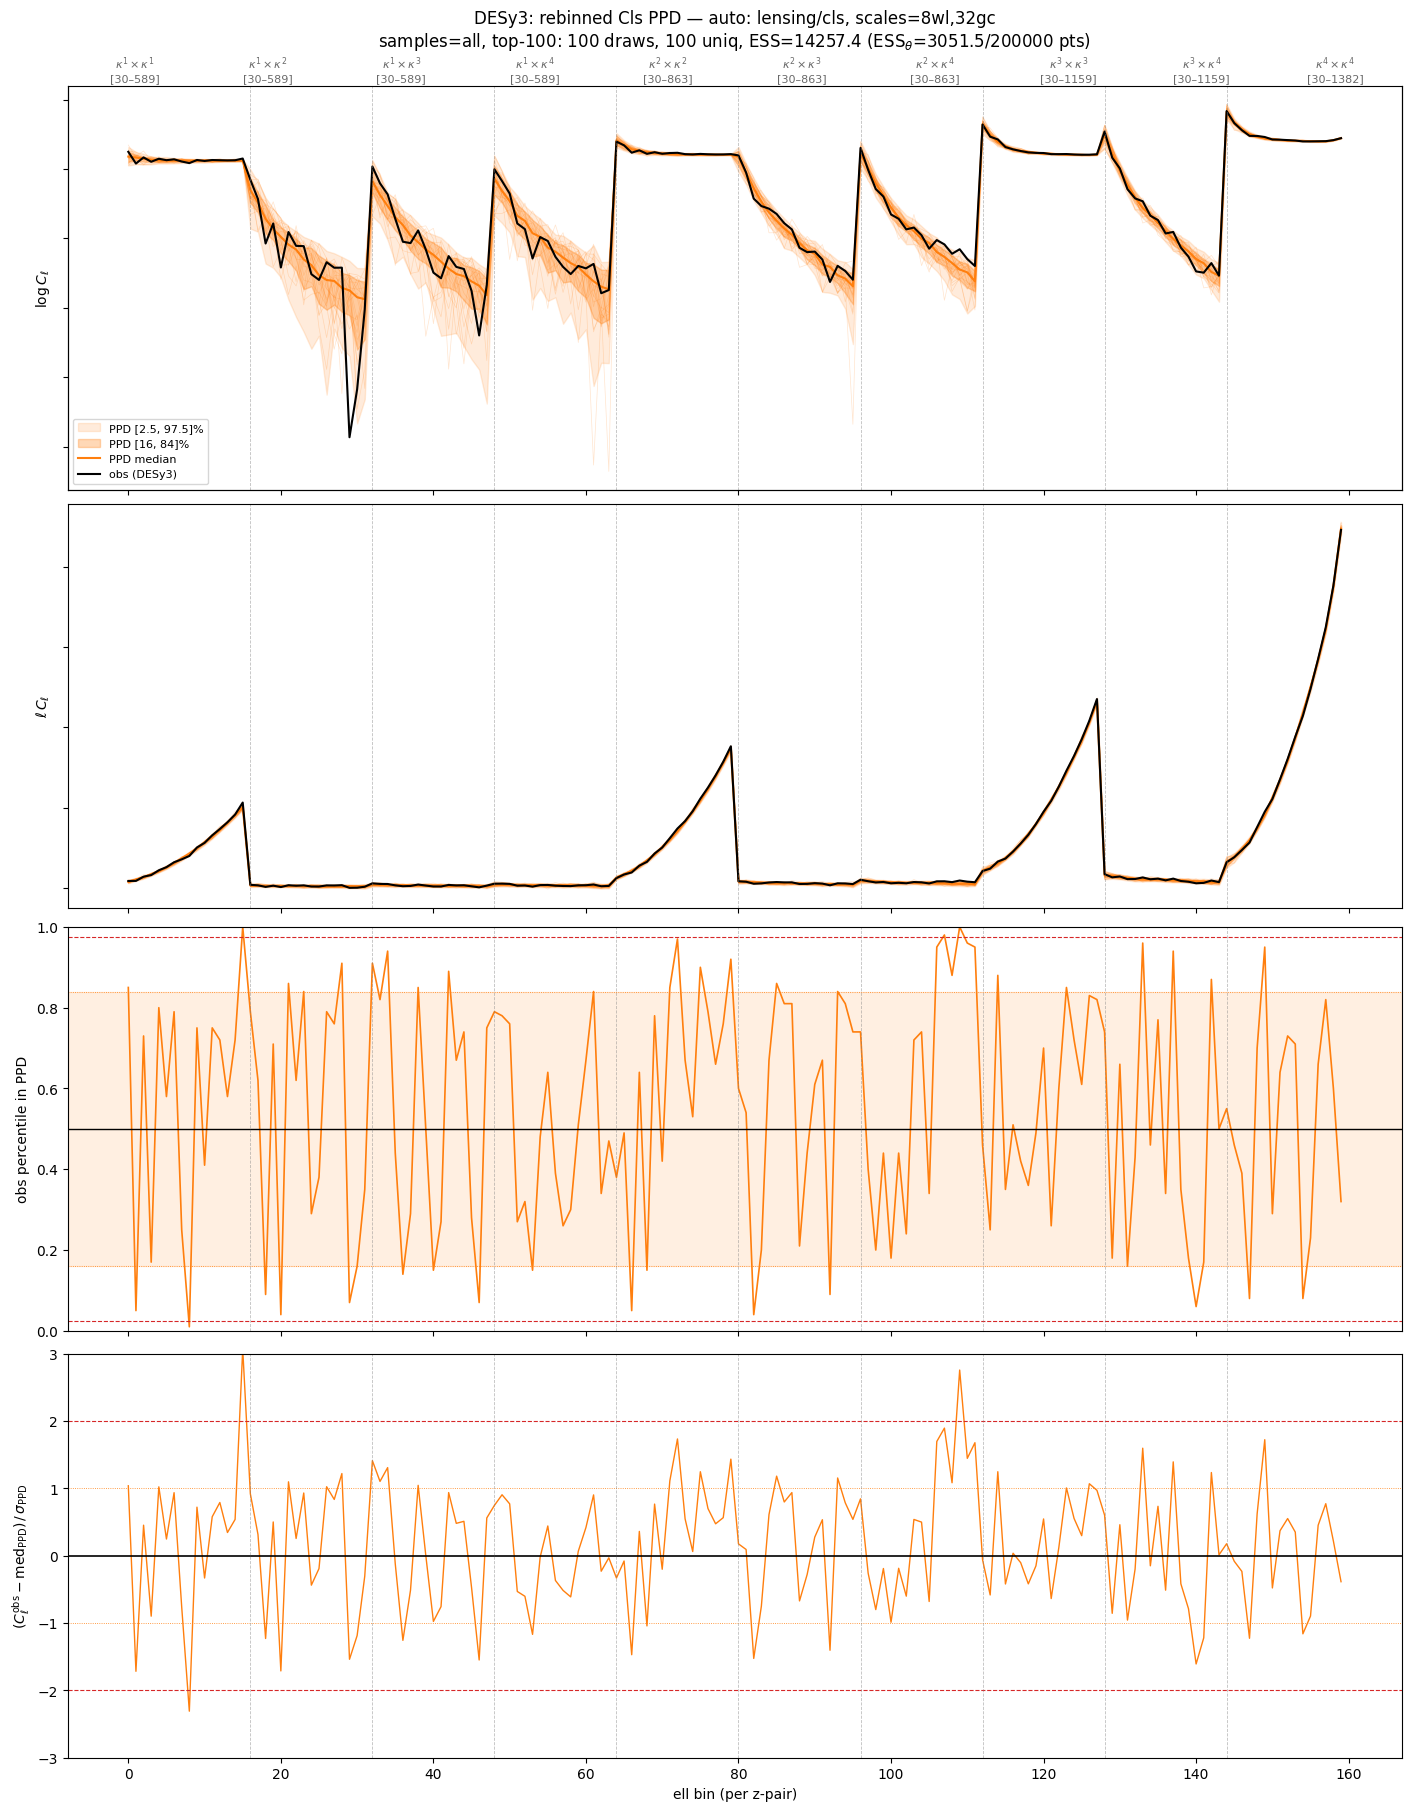

In [7]:
ppc.check_cls_marginals(
    dlss_conf=dlss_conf,
    base_dir=base_dir,
    cls_n_bins=cls_n_bins,
    scales_name=scales_name,
    grid=None,                 # reuse the preloaded cache
    sample_set="all",         # or "all" (train+test -> ~5x more astro samples, higher ESS)
    k_top=100,                # int -> top-k best-fit sims (deterministic, smooth, but biased narrow)
    apply_log=True,
    n_samples=5_000,
    percentiles=(16, 84),
    n_traces=20,
    file_label="cls",
)

plot_file = os.path.join(ppc.out_dir, f"{ppc.obs_label}_cls_marginals.png")
display(Image(filename=plot_file))


## Loop over all runs

Produce the Cls-marginals plot for **every** run in the config (maps + cls). The rebinned grid is
cached per probe selection (lensing / clustering / combined pick different channels; a maps run and a
cls run of the same probe share one grid). Probes in `skip_probes` (e.g. `2x2pt`, which has no PPC
nuisance mapping) are skipped, and any run that fails (e.g. a maps grid that disagrees with the
cache) is reported and skipped so the loop continues.

In [12]:
obs_label = "DESy3"
sample_set = "test"        # "test" or "all" (train+test, higher ESS)
k_top = 1000               # None -> importance; int -> top-k best-fit sims (biased narrow)
skip_probes = set(ppc_conf.get("skip_probes", []))

grid_cache = {}   # probe-flags -> (cls_full, real_idx_full)
plot_files = {}   # "data/probe" -> png path

for r in run_ppc.iter_runs(runs_conf):
    tag = f"{r['data']}/{r['probe']}"
    if r["probe"] in skip_probes:
        print(f"skip   {tag} (in skip_probes)")
        continue
    try:
        ppc_r = run_ppc.make_ppc(msfm_config, cosmo_params, seed, r, flow_conf=flow_conf, n_flows=n_flows)
        ppc_r.setup_flow(
            rep_probe=ppc_r.probe1_label,
            obs_probe=ppc_r.probe1_label,
            retrain=False,
            fit_kwargs={"n_epochs": 30, "run_c2st": False},
        )
        ppc_r._set_observation(obs_label=obs_label)

        flags = ppc_r._PROBE_NAME_TO_CLS_FLAGS[ppc_r.obs_probe_name]
        key = tuple(sorted(flags.items()))
        if key not in grid_cache:
            grid_cache[key] = cls_preprocessing.load_rebinned_cls_grid(
                data_dir=base_dir, msfm_conf=ppc_r.conf, dlss_conf=dlss_conf,
                cls_n_bins=cls_n_bins, scales_name=scales_name, **flags,
            )

        plot_files[tag] = ppc_r.check_cls_marginals(
            dlss_conf=dlss_conf, base_dir=base_dir, cls_n_bins=cls_n_bins,
            scales_name=scales_name, grid=grid_cache[key],
            sample_set=sample_set, k_top=k_top,
            apply_log=True, n_samples=5_000, percentiles=(16, 84), n_traces=20,
            file_label="cls",
        )
        print(f"OK     {tag} -> {plot_files[tag]}")
    except Exception as e:
        print(f"FAILED {tag}: {type(e).__name__}: {e}")

print(f"\nproduced {len(plot_files)} plot(s)")


26-06-26 14:10:24       ppc.py INF   Loading lensing data 
26-06-26 14:10:24 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/maps/lensing/v8_cls/preds_300000.h5 
26-06-26 14:10:24 input_output INF   grid_preds.shape = (200000, 6) 
26-06-26 14:10:24 input_output INF   grid_cosmos.shape = (200000, 6) 
26-06-26 14:10:24 input_output INF   DESy3 with shape (6,) 
26-06-26 14:10:24 input_output INF   DESy3_no_psi_rot with shape (6,) 
26-06-26 14:10:24 input_output INF   box_size_mean with shape (6,) 
26-06-26 14:10:24 input_output INF   box_size_stack with shape (80, 6) 
26-06-26 14:10:24 input_output INF   fiducial_bench_dmo_mean with shape (6,) 
26-06-26 14:10:24 input_output INF   fiducial_bench_dmo_stack with shape (80, 6) 
26-06-26 14:10:24 input_output INF   fiducial_bench_mean with shape (6,) 
26-06-26 14:10:24 input_output INF   fiducial_bench_nla_per_shell_mean with shape (6,) 
26-06-26 14:10:24 input_output INF   fiducial_b

## Show all plots

### maps/lensing

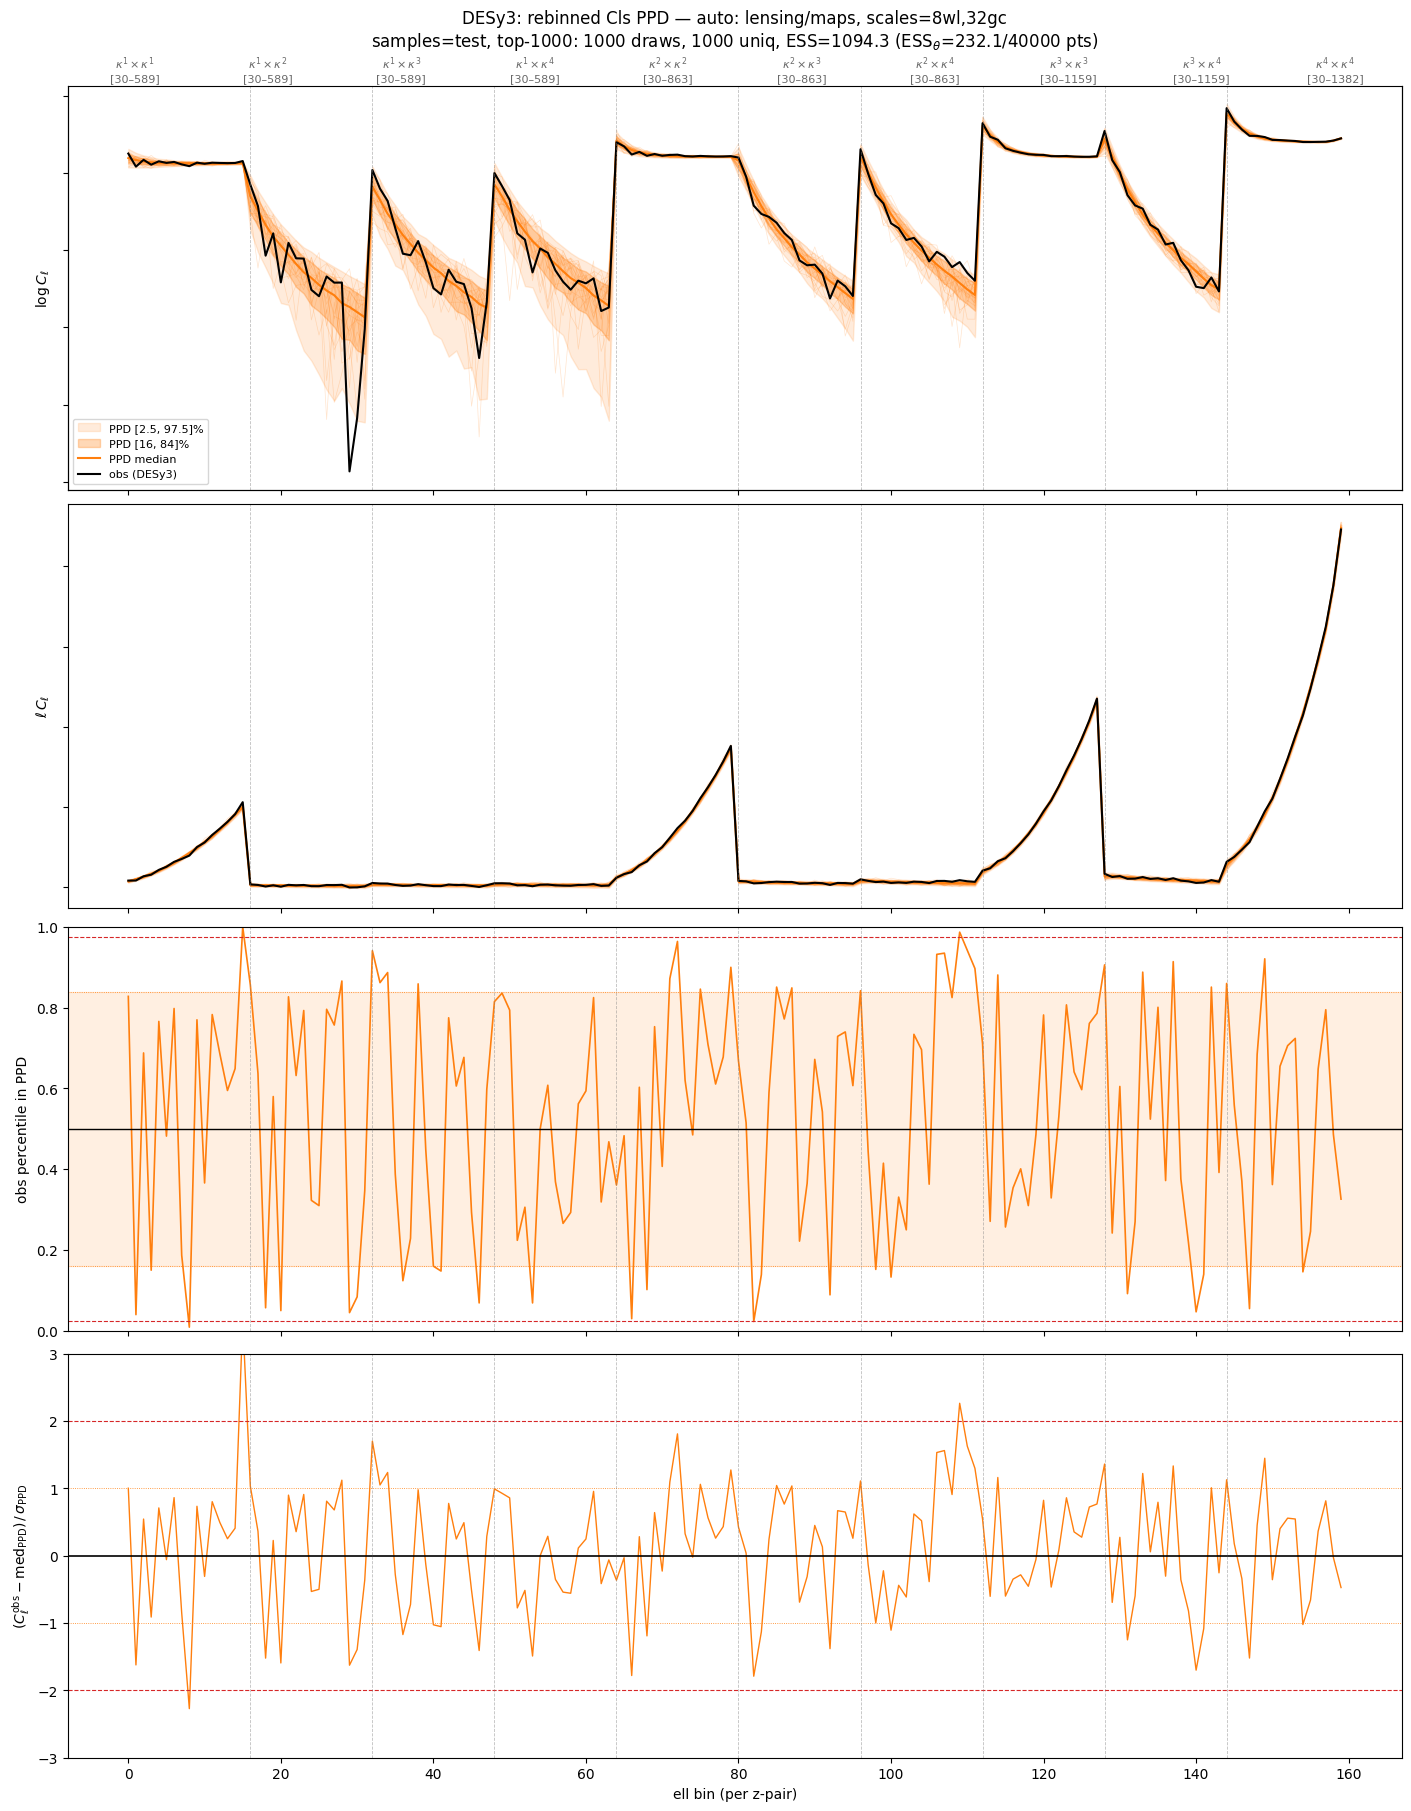

### maps/clustering

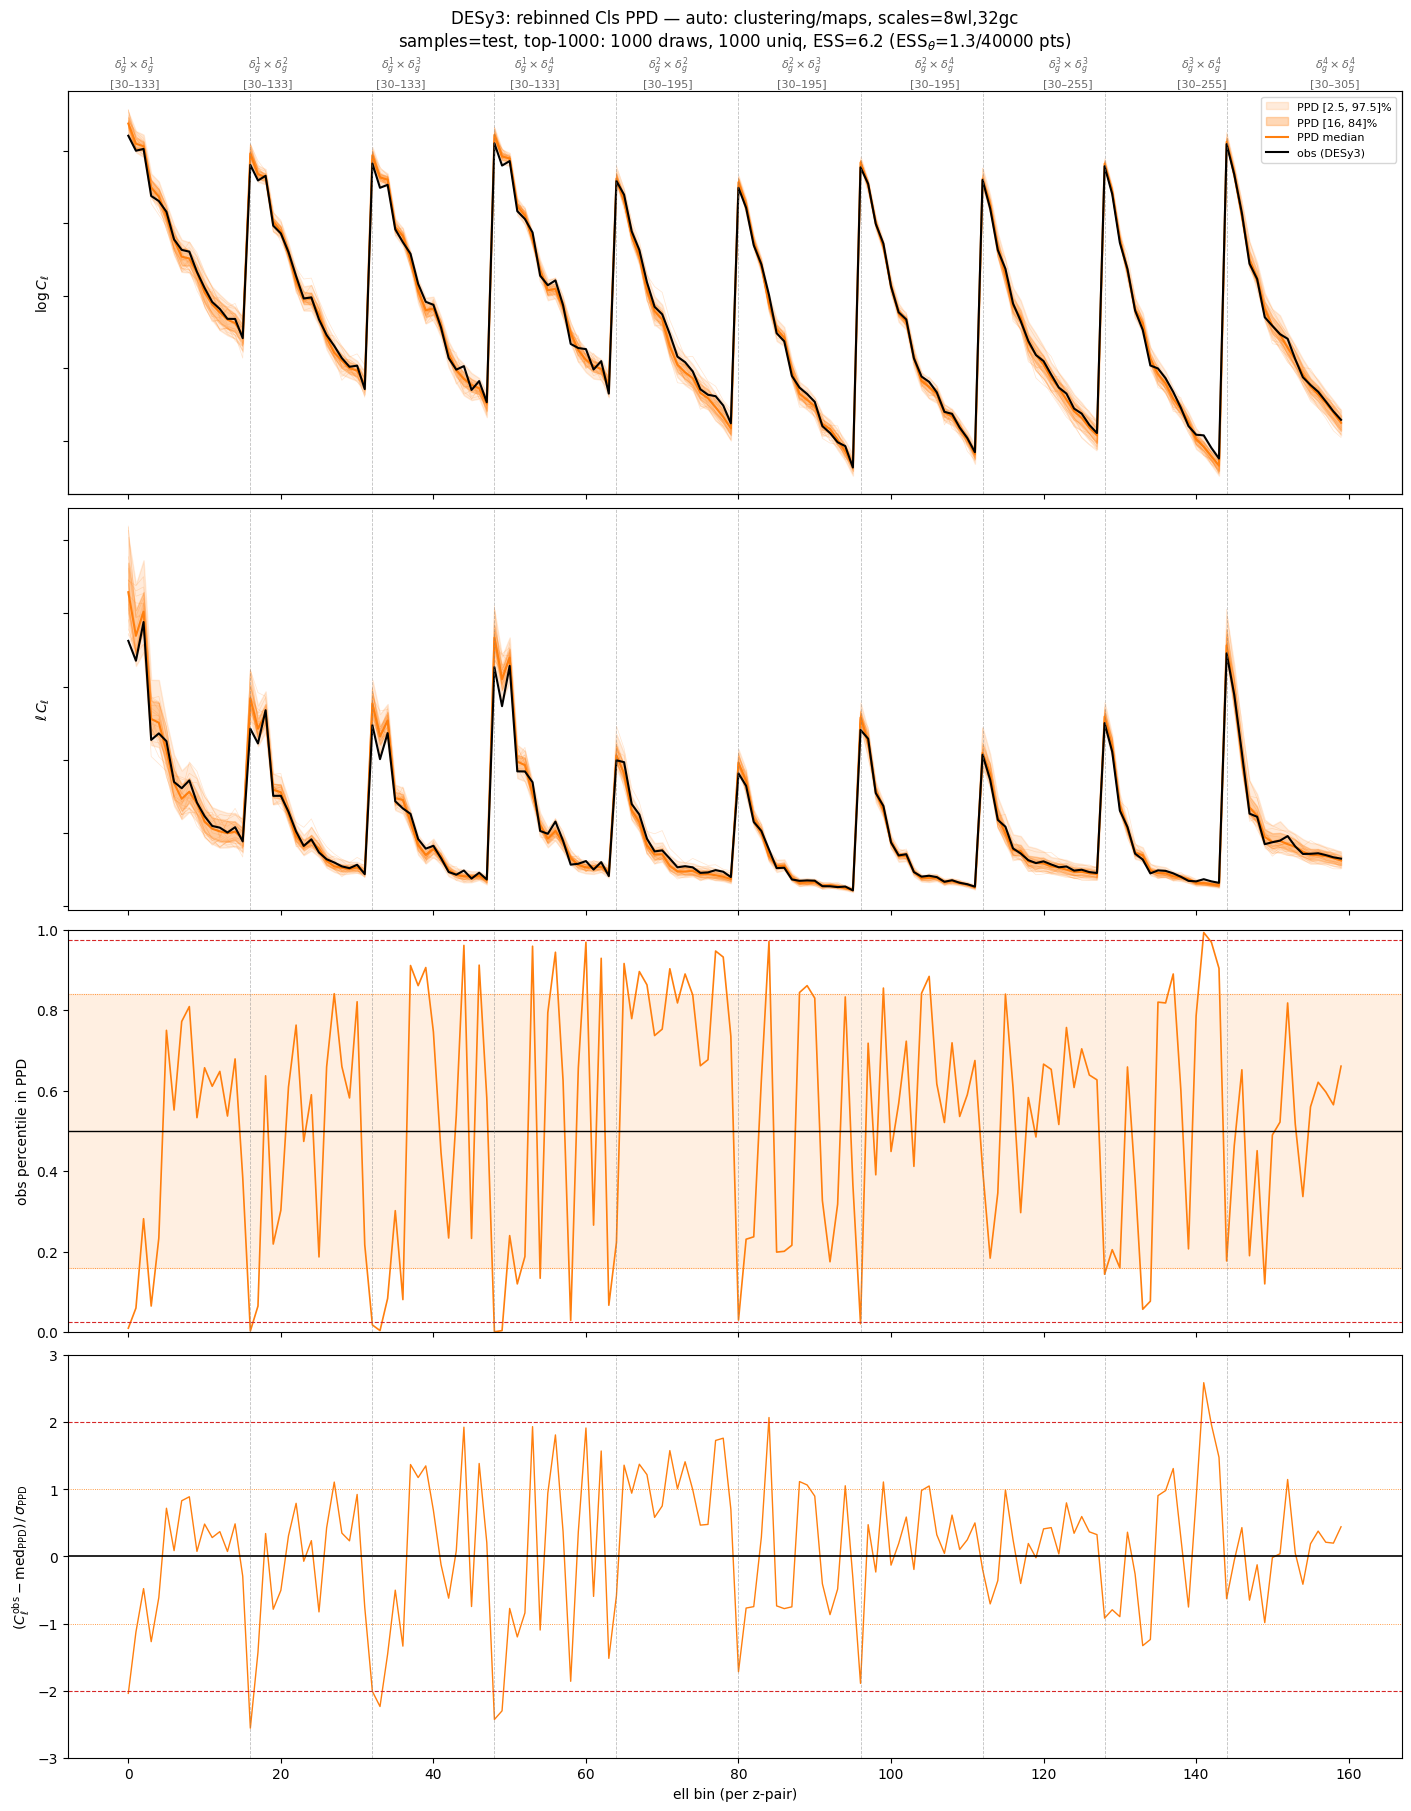

### maps/combined

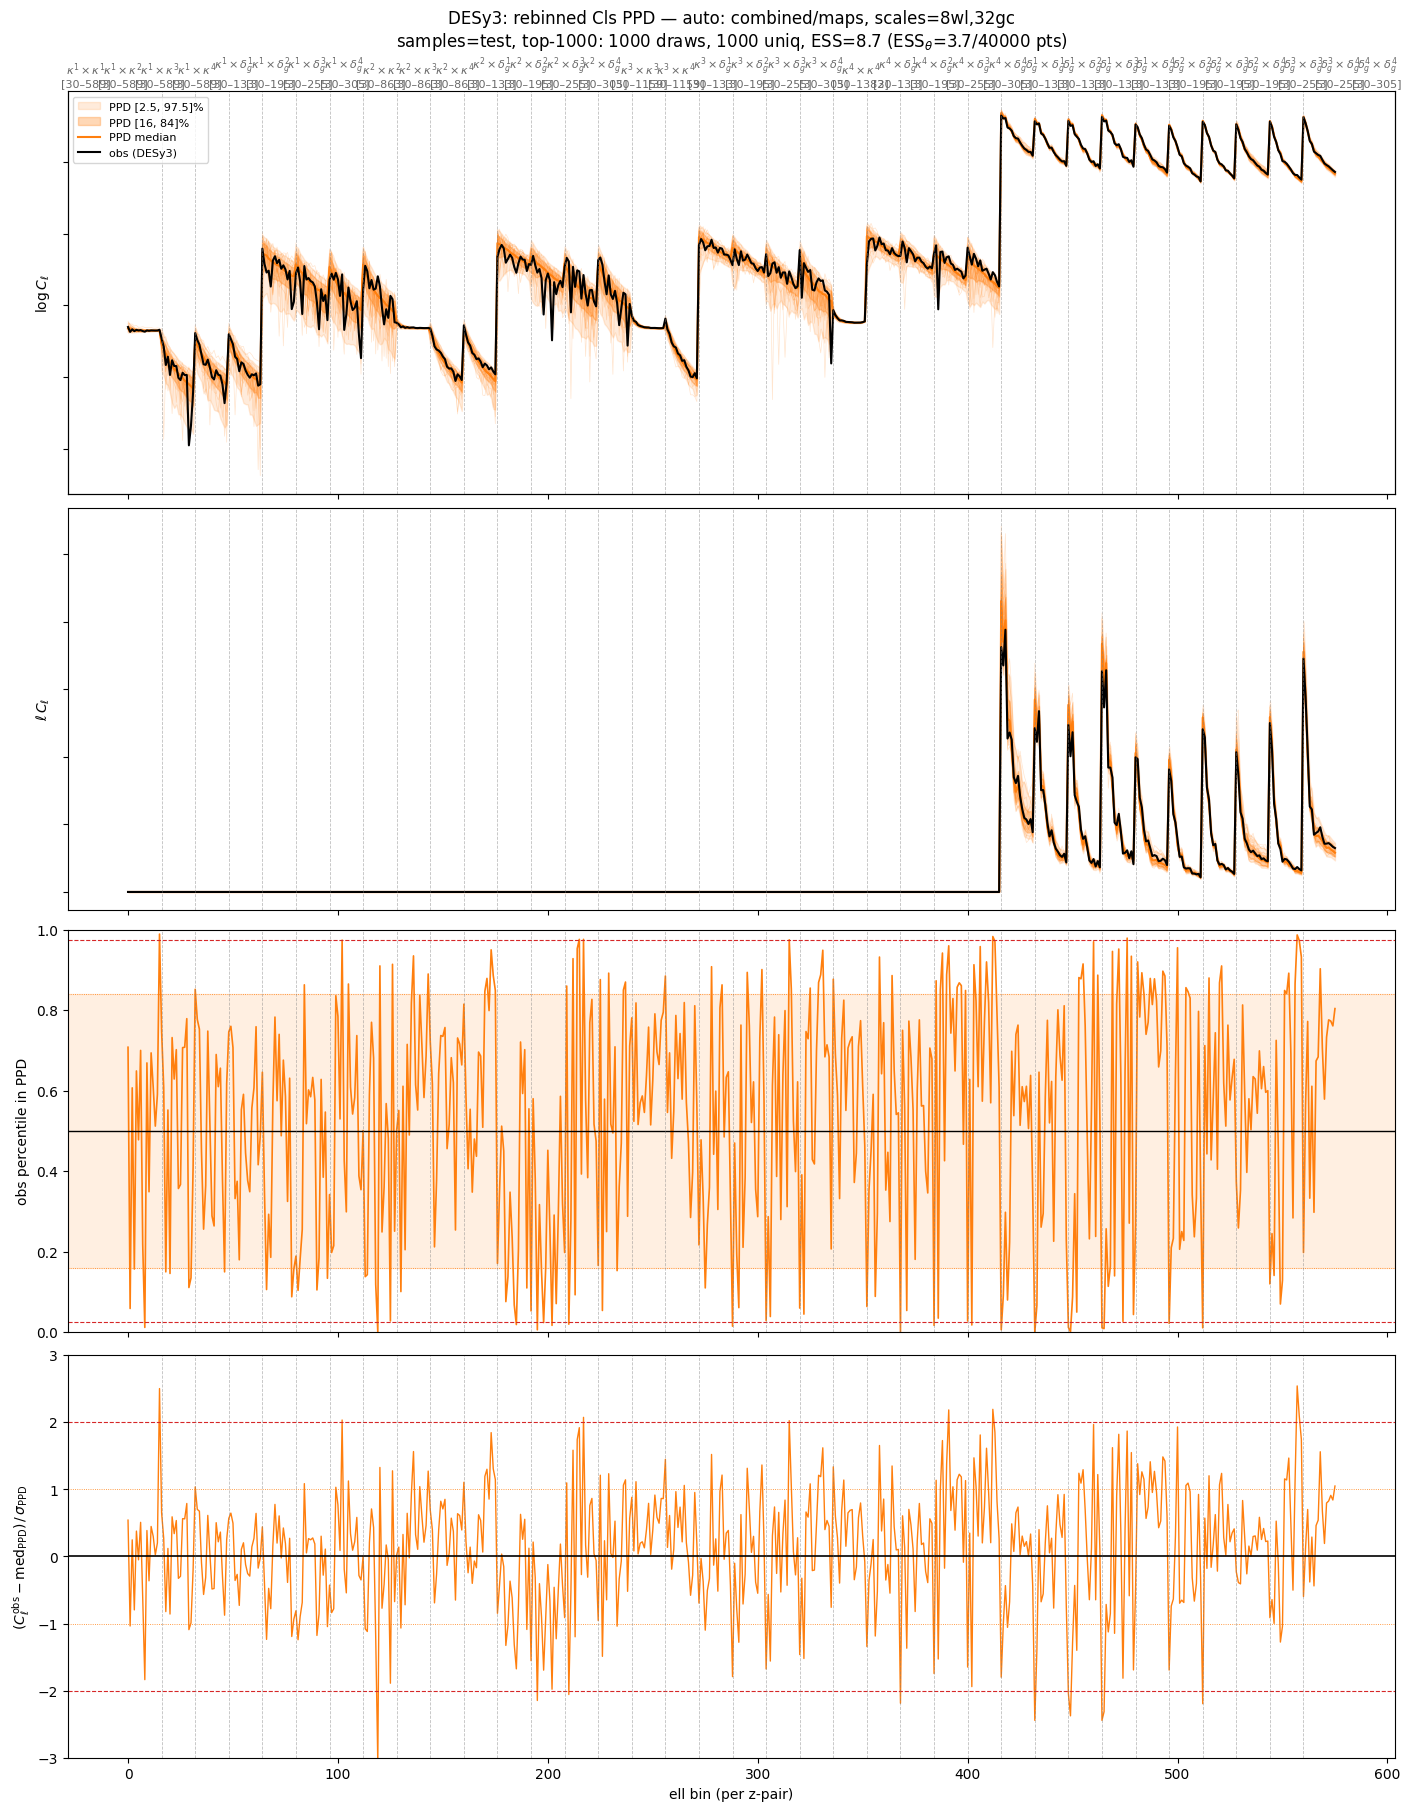

### cls/lensing

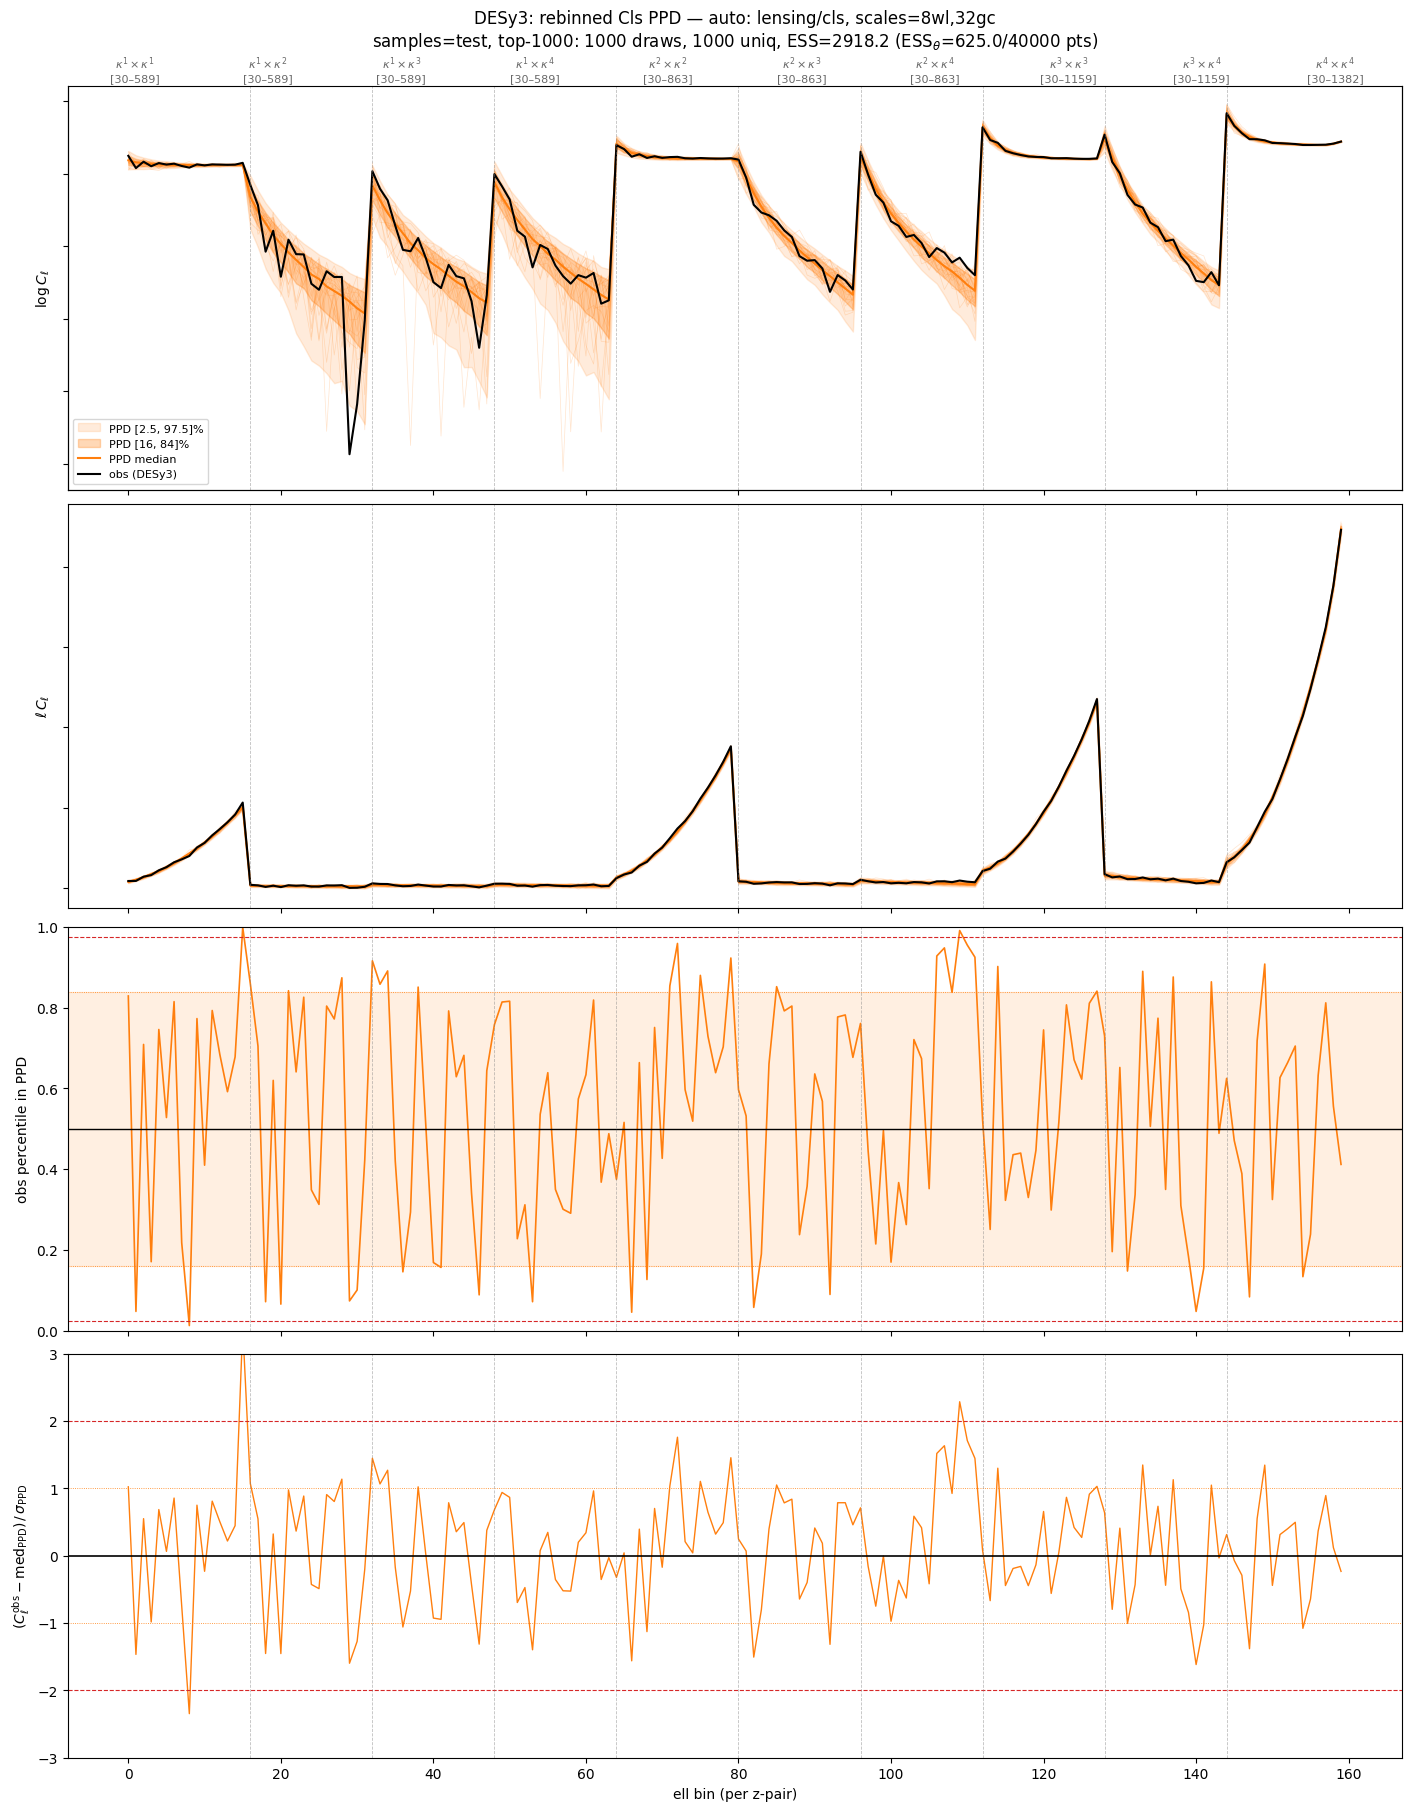

### cls/clustering

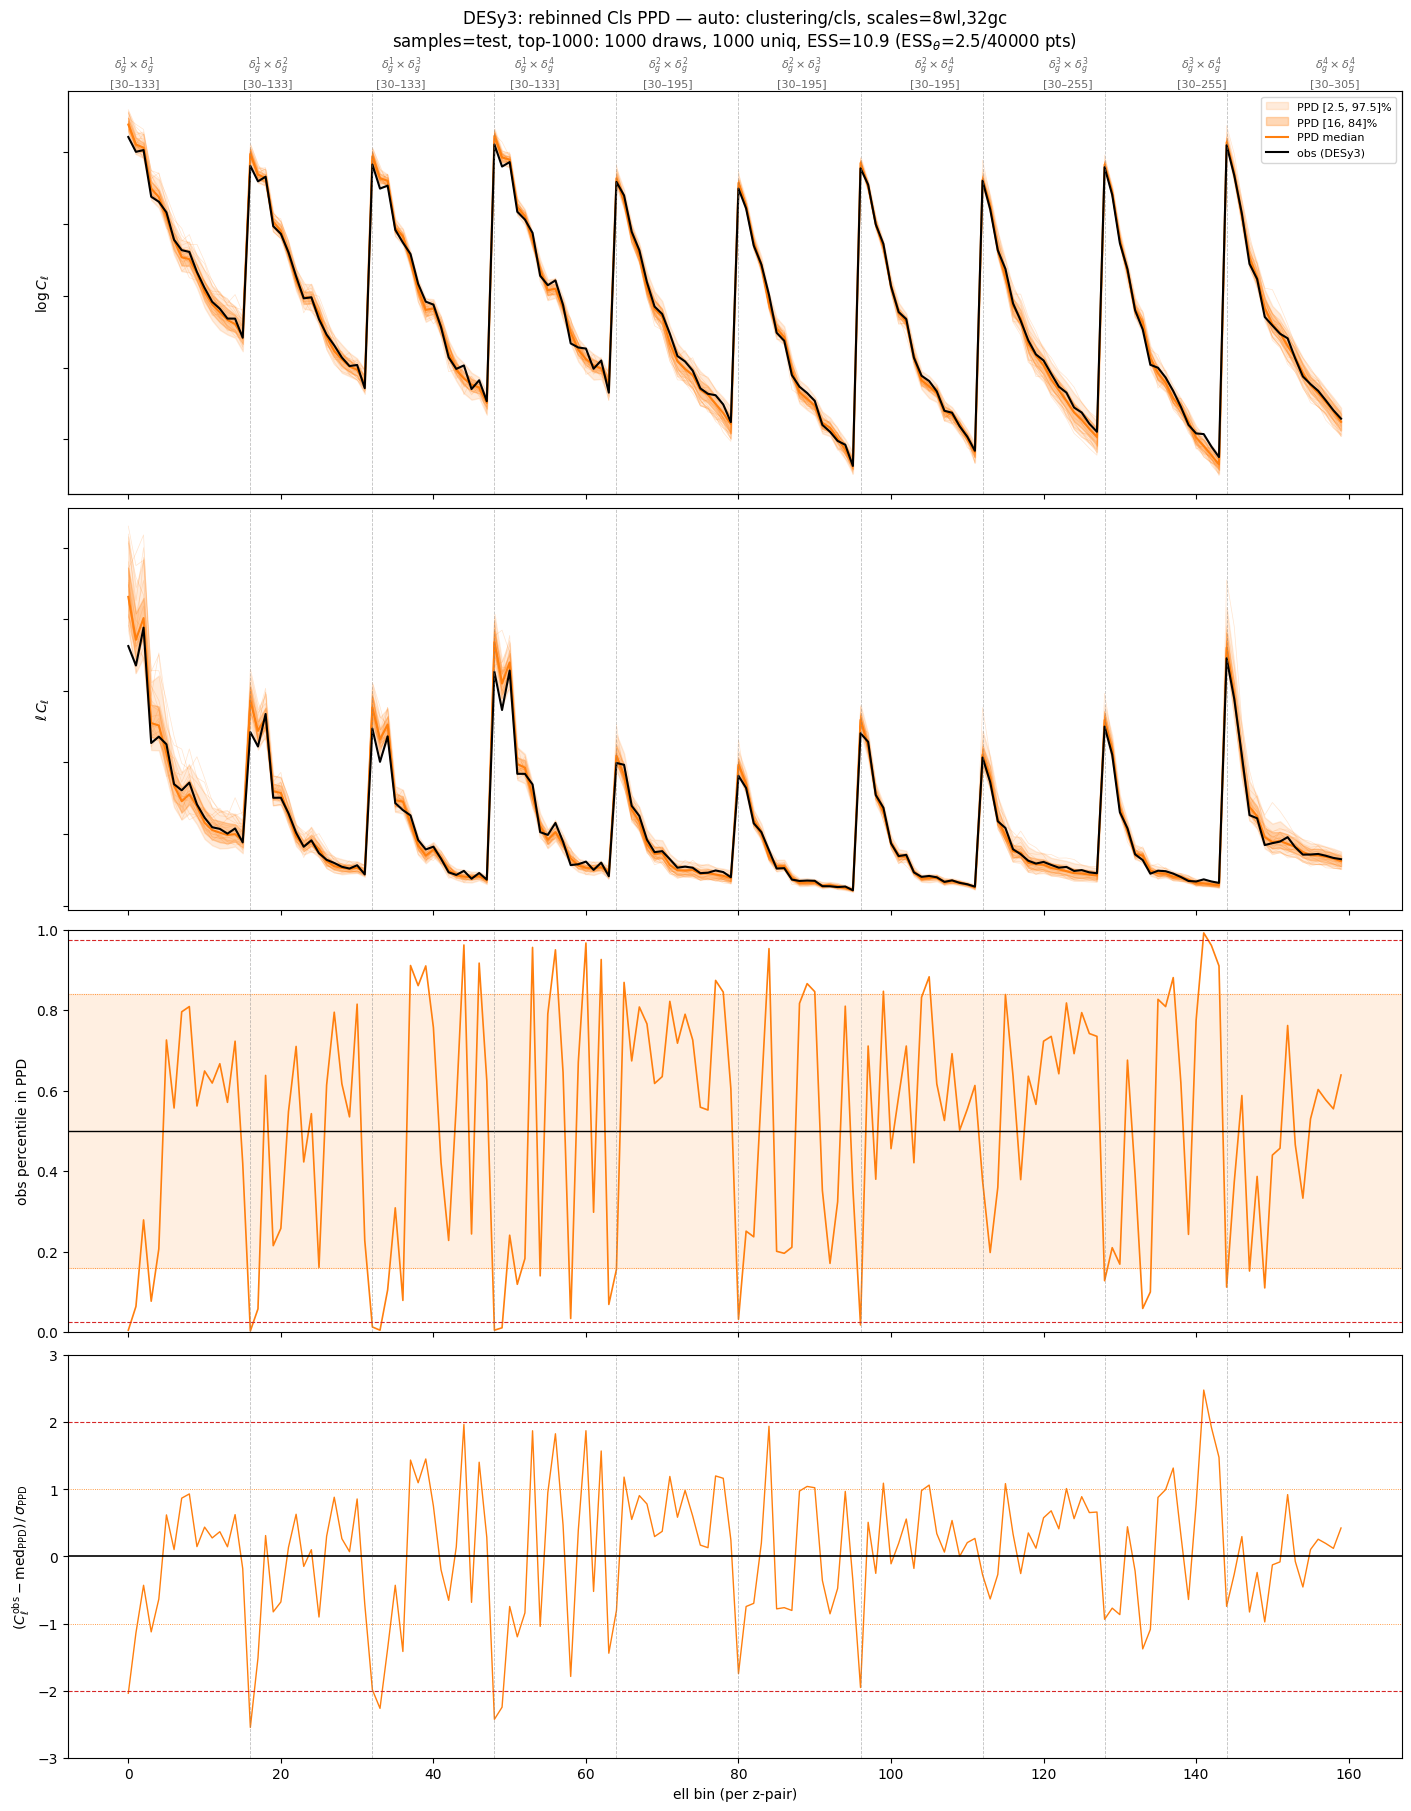

### cls/combined

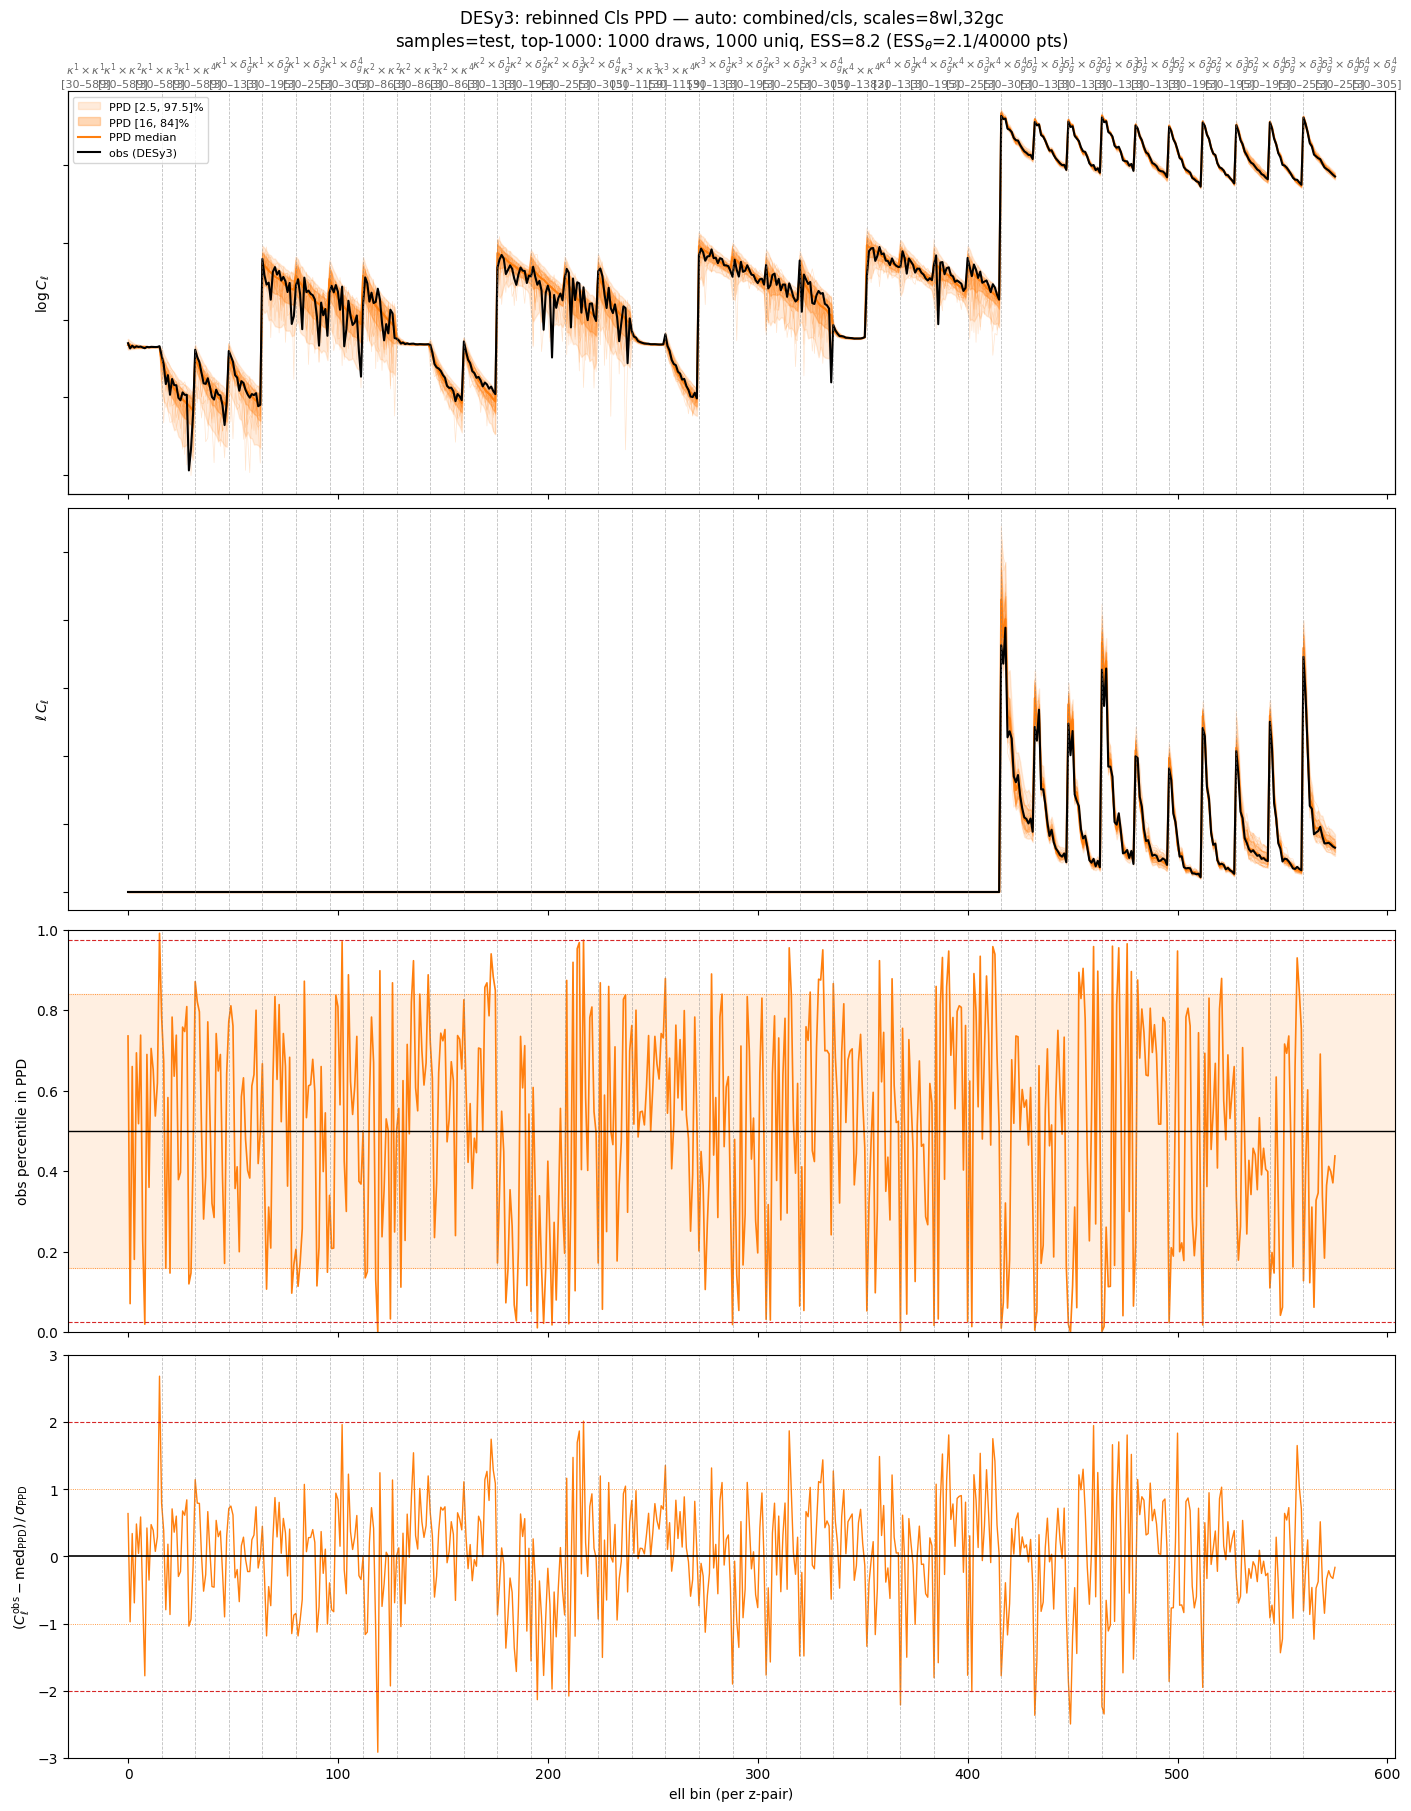

In [13]:
from IPython.display import Markdown

for tag, pf in plot_files.items():
    display(Markdown(f"### {tag}"))
    display(Image(filename=pf))
